# **EXPERIMENT_4** - Wine Dataset
**Import Required Libraries**

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

**Load the Wine Dataset**

In [19]:
from google.colab import drive
drive.mount('/content/drive')
df=pd.read_csv("/content/drive/MyDrive/Datasets/wine.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Explore The Dataset**

In [20]:
print("First 2 rows of the dataset:\n",df.head(2))
print("Shape of the Dataset:",df.shape)
print("Number of columns:\n",df.columns)

First 2 rows of the dataset:
    Alcohol  Malic_acid   Ash  Alcalinity_of_ash  Magnesium  Total_phenols  \
0        1       14.23  1.71               2.43       15.6            127   
1        1       13.20  1.78               2.14       11.2            100   

   Flavanoids  Nonflavanoid_phenols  Proanthocyanins  Color_intensity   Hue  \
0        2.80                  3.06             0.28             2.29  5.64   
1        2.65                  2.76             0.26             1.28  4.38   

   OD280_OD315  Proline  
0         1.04     3.92  
1         1.05     3.40  
Shape of the Dataset: (178, 13)
Number of columns:
 Index(['Alcohol', 'Malic_acid', 'Ash', 'Alcalinity_of_ash', 'Magnesium',
       'Total_phenols', 'Flavanoids', 'Nonflavanoid_phenols',
       'Proanthocyanins', 'Color_intensity', 'Hue', 'OD280_OD315', 'Proline'],
      dtype='object')


In [21]:
# Check duplicates
print("Number of duplicate rows:", df.duplicated().sum())
# Check missing values
print("Missing values per column:\n", df.isnull().sum())

Number of duplicate rows: 0
Missing values per column:
 Alcohol                 0
Malic_acid              0
Ash                     0
Alcalinity_of_ash       0
Magnesium               0
Total_phenols           0
Flavanoids              0
Nonflavanoid_phenols    0
Proanthocyanins         0
Color_intensity         0
Hue                     0
OD280_OD315             0
Proline                 0
dtype: int64


**Separate Features and Target**

In [22]:
X,Y= df.iloc[:,1:],df.iloc[:,0]

**Split the Dataset**

In [23]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3,stratify=Y,random_state=42)


**Initialize Decision Tree Classifier**

In [24]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, Y_train)

DecisionTreeClassifier(random_state=42)

**Train the Decision Tree Model**

In [25]:
# BEFORE PRUNING: No restrictions
dt_before_pruning = DecisionTreeClassifier(
    criterion="gini",
    splitter="best",
    max_depth=None,   # No pruning
    random_state=42
)
dt_before_pruning.fit(X_train, Y_train)

DecisionTreeClassifier(random_state=42)

**Predict & Evaluate the Model**

In [26]:
Y_pred_before = dt_before_pruning.predict(X_test)

print("Accuracy (Before Pruning):",
      accuracy_score(Y_test, Y_pred_before))

print("\nClassification Report (Before Pruning):\n",
      classification_report(Y_test, Y_pred_before))

print("\nConfusion matrix (Before Pruning):\n",
      confusion_matrix(Y_test, Y_pred_before))




Accuracy (Before Pruning): 0.9259259259259259

Classification Report (Before Pruning):
               precision    recall  f1-score   support

           1       0.89      0.89      0.89        18
           2       0.90      0.90      0.90        21
           3       1.00      1.00      1.00        15

    accuracy                           0.93        54
   macro avg       0.93      0.93      0.93        54
weighted avg       0.93      0.93      0.93        54


Confusion matrix (Before Pruning):
 [[16  2  0]
 [ 2 19  0]
 [ 0  0 15]]


**Visualize the Decision Tree**

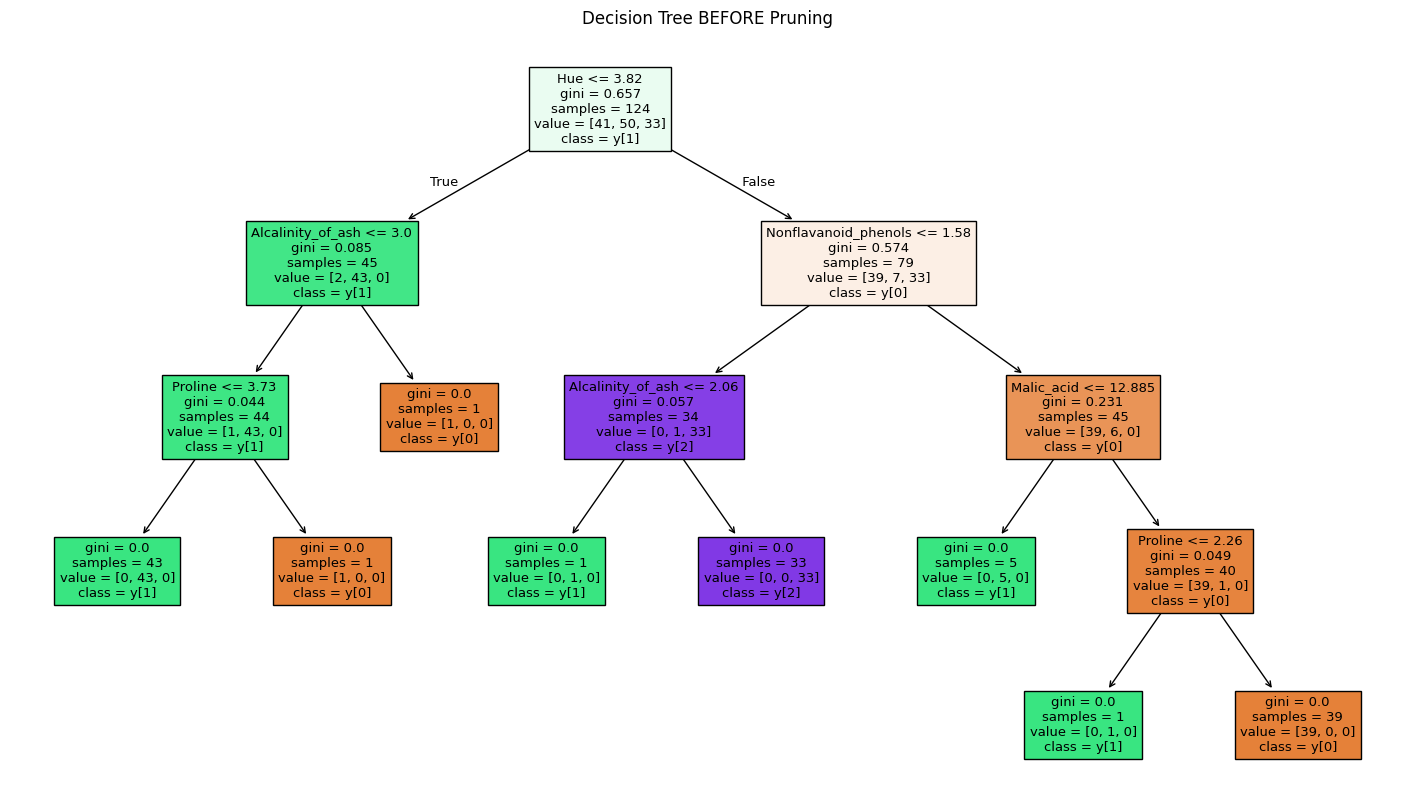

In [27]:
plt.figure(figsize=(18,10))
plot_tree(
    dt_before_pruning,
    feature_names=X.columns,
    class_names= True ,
    filled=True,
    max_depth=None  # visualization only
)
plt.title("Decision Tree BEFORE Pruning")
plt.show()

In [28]:
# AFTER PRUNING: Pre-pruned tree
dt_after_pruning = DecisionTreeClassifier(
    criterion="gini",
    splitter="best",
    max_depth=3,       # Pre-pruning applied
    random_state=42
)

dt_after_pruning.fit(X_train, Y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [29]:
Y_pred_after = dt_after_pruning.predict(X_test)

print("Accuracy (After Pruning):",
      accuracy_score(Y_test, Y_pred_after))

print("\nClassification Report (After Pruning):\n",
      classification_report(Y_test, Y_pred_after))

print("\nConfusion_matrix (After Pruning):\n",
      confusion_matrix(Y_test, Y_pred_after))

Accuracy (After Pruning): 0.9259259259259259

Classification Report (After Pruning):
               precision    recall  f1-score   support

           1       0.89      0.89      0.89        18
           2       0.90      0.90      0.90        21
           3       1.00      1.00      1.00        15

    accuracy                           0.93        54
   macro avg       0.93      0.93      0.93        54
weighted avg       0.93      0.93      0.93        54


Confusion_matrix (After Pruning):
 [[16  2  0]
 [ 2 19  0]
 [ 0  0 15]]


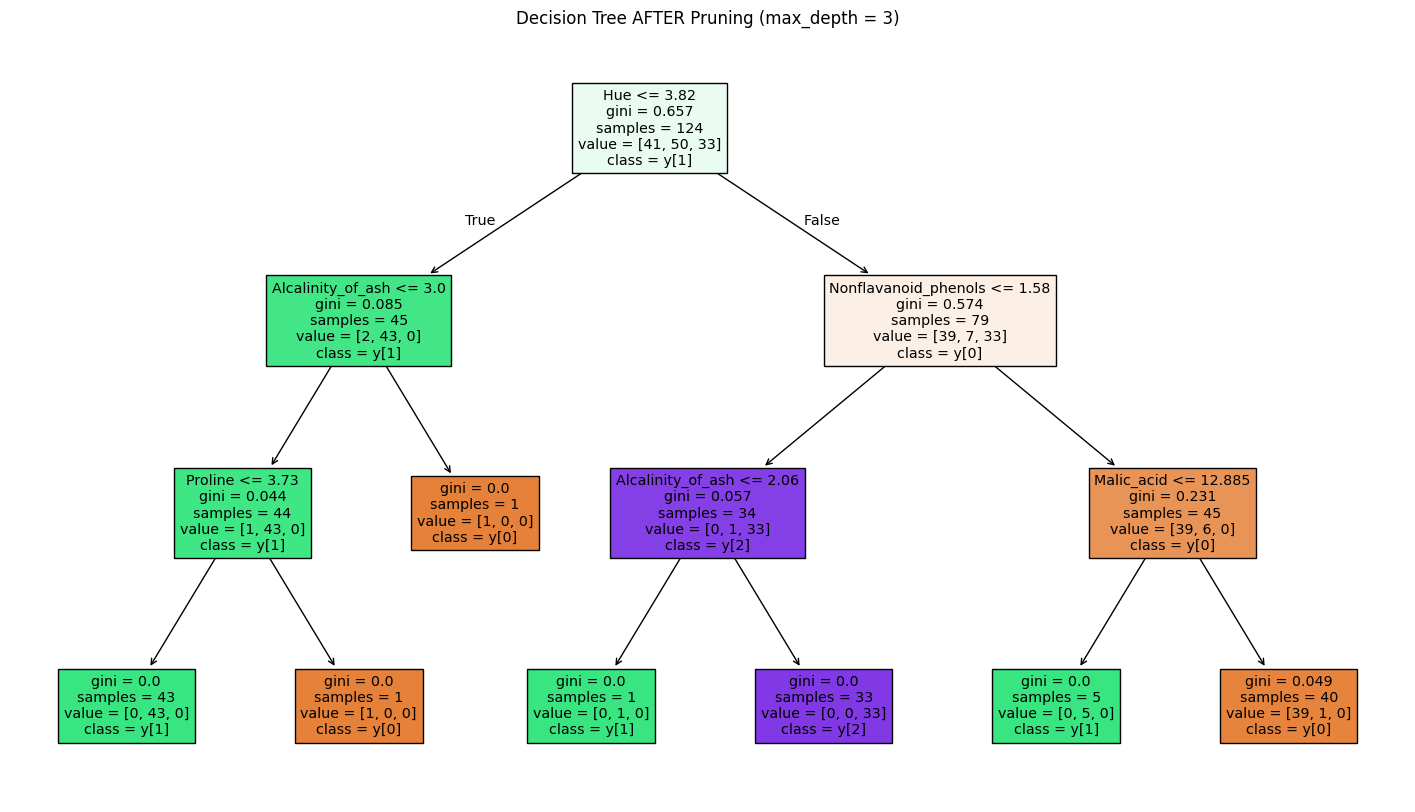

In [30]:
plt.figure(figsize=(18,10))
plot_tree(
    dt_after_pruning,
    feature_names=X.columns,
    class_names= True,
    filled=True
)
plt.title("Decision Tree AFTER Pruning (max_depth = 3)")
plt.show()

In [35]:
'''# 1. Train a full, unpruned tree
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, Y_train)

# 2. Get the "alphas" (pruning path) to find the best value
path = full_tree.cost_complexity_pruning_path(X_train, Y_train)
ccp_alphas = path.ccp_alphas'''

# 3. Re-train using a specific alpha (e.g., 0.01)
dt_post_pruned = DecisionTreeClassifier(ccp_alpha=0.01, random_state=42)
dt_post_pruned.fit(X_train, Y_train)

DecisionTreeClassifier(ccp_alpha=0.01, random_state=42)

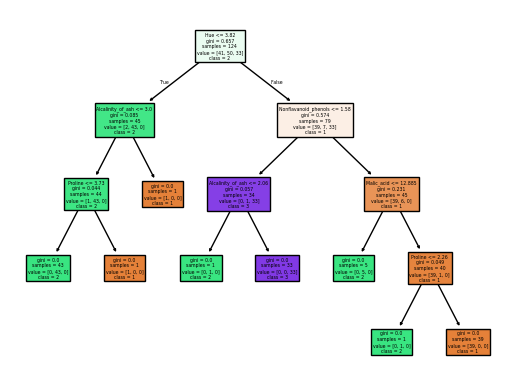

In [36]:
plot_tree(dt_post_pruned , feature_names = X.columns ,  class_names=[str(c) for c in dt_post_pruned.classes_] , filled = True)
plt.show()